# 3D U-Net for Medical Image Segmentation (Decathlon Task06 Lung)

This notebook implements an advanced 3D U-Net training pipeline in PyTorch for 3D CT volume segmentation.
Target dataset: **Medical Segmentation Decathlon (Task06 Lung)**.

Key Optimizations & Enhancements:
1. **Foreground-Centric 3D Patch Sampling** (`FG_PROB = 0.8`)
2. **Multi-Patch Epoch Sampling** (`PATCHES_PER_VOLUME = 4` -> 204 training patches per epoch)
3. **3D Spatial Data Augmentation** (Random 3D Flips along Depth, Height, and Width axes)
4. **Weighted BCE + Dice Loss** (`0.3 * BCE + 0.7 * Dice Loss`)
5. **Cosine Annealing LR & Early Stopping** with `tqdm` progress bars
6. **Multi-Planar 3D Visualization** (Axial, Coronal, Sagittal projections)


In [8]:
# 1. Imports and Device Setup
import os
import sys
import ssl
import json
import glob
import random
import time
from typing import Tuple, Dict, Optional, List

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# Fix SSL certificates on macOS Python
ssl._create_default_https_context = ssl._create_unverified_context

# Select compute device (MPS for Apple Silicon, CUDA for NVIDIA GPU, CPU fallback)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using compute device: {device}')


Using compute device: cuda


# 2. Hyperparameters & Optimization Settings

In [9]:
# ---------------------------------------------------------------------------
# Hyperparameters & Optimization Settings
# ---------------------------------------------------------------------------
SEED = 42
BATCH_SIZE = 2
CROP_SIZE = (64, 128, 128)      # 3D Patch size: (Depth, Height, Width)
IN_CHANNELS = 1
OUT_CHANNELS = 1                # Binary segmentation: 0 = Background, 1 = Tumor
INIT_FEATURES = 32
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 20                     # Increased epochs for 3D convergence
PATCHES_PER_VOLUME = 4          # Sample 4 3D patches per volume per epoch
CT_MIN = -1000.0                # Minimum Hounsfield Unit (HU) for CT clipping
CT_MAX = 400.0                  # Maximum Hounsfield Unit (HU) for CT clipping
FG_PROB = 0.8                   # 80% chance to center patch crop on a tumor lesion

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f'Hyperparameters loaded. Patch crop size: {CROP_SIZE} | Patches/Volume: {PATCHES_PER_VOLUME}')


Hyperparameters loaded. Patch crop size: (64, 128, 128) | Patches/Volume: 4


# 3. Dataset Preparation (Task06 Lung)

In [10]:
# Helper function to resolve NIfTI files inside nested directories
def resolve_nifti_path(path: str) -> str:
    if os.path.isdir(path):
        contents = [os.path.join(path, f) for f in os.listdir(path) if not f.startswith(".")]
        if contents:
            return contents[0]
    return path

def get_dataset_path() -> str:
    # 1. Check local data folder
    local_data = os.path.abspath("./data/Task06_Lung")
    if os.path.exists(local_data) and os.path.exists(os.path.join(local_data, "imagesTr")):
        print(f"Dataset found in local directory: {local_data}")
        return local_data

    # 2. Check local Kagglehub cache
    cache_dir = os.path.expanduser("~/.cache/kagglehub/datasets/vivekprajapati2048/medical-segmentation-decathlon-lung/versions/3")
    if os.path.exists(os.path.join(cache_dir, "imagesTr")):
        print(f"Dataset found in local cache: {cache_dir}")
        return cache_dir

    # 3. Fallback: Download via kagglehub
    import kagglehub
    print("Downloading dataset via kagglehub...")
    dataset_path = kagglehub.dataset_download("vivekprajapati2048/medical-segmentation-decathlon-lung")
    print(f"Downloaded to: {dataset_path}")
    return dataset_path

dataset_path = get_dataset_path()


Downloaded to: /kaggle/input/datasets/vivekprajapati2048/medical-segmentation-decathlon-lung


# 4. Enhanced 3D PyTorch Dataset Class with 3D Data Augmentation

In [11]:
class Lung3DUnetDataset(Dataset):
    def __init__(
        self,
        dataset_path: str,
        file_pairs: List[Tuple[str, Optional[str]]],
        crop_size: Tuple[int, int, int] = (64, 128, 128),
        patches_per_volume: int = 1,
        ct_min: float = -1000.0,
        ct_max: float = 400.0,
        fg_prob: float = 0.8,
        is_train: bool = True
    ):
        super().__init__()
        self.dataset_path = dataset_path
        self.pairs = file_pairs
        self.crop_size = crop_size
        self.patches_per_volume = patches_per_volume
        self.ct_min = ct_min
        self.ct_max = ct_max
        self.fg_prob = fg_prob
        self.is_train = is_train

    def __len__(self) -> int:
        return len(self.pairs) * self.patches_per_volume

    def _normalize_ct(self, volume: np.ndarray) -> np.ndarray:
        clipped = np.clip(volume, self.ct_min, self.ct_max)
        normalized = (clipped - self.ct_min) / (self.ct_max - self.ct_min)
        return normalized.astype(np.float32)

    def _crop_3d_patch(
        self,
        image: np.ndarray,
        label: Optional[np.ndarray]
    ) -> Tuple[np.ndarray, Optional[np.ndarray]]:
        cd, ch, cw = self.crop_size
        d, h, w = image.shape

        pad_d = max(0, cd - d)
        pad_h = max(0, ch - h)
        pad_w = max(0, cw - w)

        if pad_d > 0 or pad_h > 0 or pad_w > 0:
            pad_width = ((0, pad_d), (0, pad_h), (0, pad_w))
            image = np.pad(image, pad_width, mode="constant", constant_values=0)
            if label is not None:
                label = np.pad(label, pad_width, mode="constant", constant_values=0)
            d, h, w = image.shape

        fg_indices = np.argwhere(label > 0) if (label is not None and np.any(label > 0)) else []

        if len(fg_indices) > 0 and np.random.rand() < self.fg_prob:
            center_vox = fg_indices[np.random.randint(0, len(fg_indices))]
            start_d = max(0, min(d - cd, center_vox[0] - cd // 2))
            start_h = max(0, min(h - ch, center_vox[1] - ch // 2))
            start_w = max(0, min(w - cw, center_vox[2] - cw // 2))
        else:
            start_d = np.random.randint(0, d - cd + 1) if self.is_train else (d - cd) // 2
            start_h = np.random.randint(0, h - ch + 1) if self.is_train else (h - ch) // 2
            start_w = np.random.randint(0, w - cw + 1) if self.is_train else (w - cw) // 2

        cropped_img = image[start_d:start_d + cd, start_h:start_h + ch, start_w:start_w + cw]
        cropped_lbl = label[start_d:start_d + cd, start_h:start_h + ch, start_w:start_w + cw] if label is not None else None

        return cropped_img, cropped_lbl

    def _apply_3d_augmentations(
        self,
        image: np.ndarray,
        label: Optional[np.ndarray]
    ) -> Tuple[np.ndarray, Optional[np.ndarray]]:
        if not self.is_train:
            return image, label

        # Random Flip Depth (Axis 0)
        if random.random() > 0.5:
            image = np.flip(image, axis=0)
            if label is not None:
                label = np.flip(label, axis=0)

        # Random Flip Height (Axis 1)
        if random.random() > 0.5:
            image = np.flip(image, axis=1)
            if label is not None:
                label = np.flip(label, axis=1)

        # Random Flip Width (Axis 2)
        if random.random() > 0.5:
            image = np.flip(image, axis=2)
            if label is not None:
                label = np.flip(label, axis=2)

        return np.ascontiguousarray(image), np.ascontiguousarray(label) if label is not None else None

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        actual_idx = idx % len(self.pairs)
        img_path, lbl_path = self.pairs[actual_idx]

        img_nifti = nib.load(img_path)
        img_data = img_nifti.get_fdata(dtype=np.float32)

        lbl_data = None
        if lbl_path is not None:
            lbl_nifti = nib.load(lbl_path)
            lbl_data = lbl_nifti.get_fdata(dtype=np.float32)

        norm_img = self._normalize_ct(img_data)
        cropped_img, cropped_lbl = self._crop_3d_patch(norm_img, lbl_data)
        aug_img, aug_lbl = self._apply_3d_augmentations(cropped_img, cropped_lbl)

        tensor_img = torch.from_numpy(aug_img).unsqueeze(0)

        sample = {
            "image": tensor_img,
            "filename": os.path.basename(img_path)
        }

        if aug_lbl is not None:
            tensor_lbl = torch.from_numpy(aug_lbl).long().unsqueeze(0)
            sample["label"] = tensor_lbl

        return sample

# Collect training file pairs
images_dir = glob.glob(os.path.join(dataset_path, "**", "imagesTr"), recursive=True)[0]
labels_dir = glob.glob(os.path.join(dataset_path, "**", "labelsTr"), recursive=True)[0]

raw_img_entries = sorted([os.path.join(images_dir, f) for f in os.listdir(images_dir) if not f.startswith(".")])
lbl_dict = {f: os.path.join(labels_dir, f) for f in os.listdir(labels_dir) if not f.startswith(".")}

all_pairs = []
for img_entry in raw_img_entries:
    bname = os.path.basename(img_entry)
    resolved_img = resolve_nifti_path(img_entry)
    resolved_lbl = resolve_nifti_path(lbl_dict[bname]) if bname in lbl_dict else None
    all_pairs.append((resolved_img, resolved_lbl))

# Train / Validation Split (80% Train, 20% Validation)
val_size = int(len(all_pairs) * 0.2)
train_pairs = all_pairs[:-val_size]
val_pairs = all_pairs[-val_size:]

print(f"Base volumes: {len(all_pairs)} | Train volumes: {len(train_pairs)} | Val volumes: {len(val_pairs)}")

train_dataset = Lung3DUnetDataset(
    dataset_path, train_pairs, crop_size=CROP_SIZE,
    patches_per_volume=PATCHES_PER_VOLUME, ct_min=CT_MIN, ct_max=CT_MAX,
    fg_prob=FG_PROB, is_train=True
)
val_dataset = Lung3DUnetDataset(
    dataset_path, val_pairs, crop_size=CROP_SIZE,
    patches_per_volume=1, ct_min=CT_MIN, ct_max=CT_MAX,
    fg_prob=FG_PROB, is_train=False
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train Dataset size (with {PATCHES_PER_VOLUME} patches/vol): {len(train_dataset)} patches")
print(f"Validation Dataset size: {len(val_dataset)} patches")


Base volumes: 63 | Train volumes: 51 | Val volumes: 12
Train Dataset size (with 4 patches/vol): 204 patches
Validation Dataset size: 12 patches


# 5. 3D U-Net Architecture (`UNet3D`)

The 3D U-Net replaces 2D convolutions and pooling operations with 3D counterparts (`Conv3d`, `MaxPool3d`, `ConvTranspose3d`, `InstanceNorm3d`).
Skip connections preserve fine-grained spatial anatomy across resolution levels.


In [12]:
class DoubleConv3D(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class UNet3D(nn.Module):
    def __init__(self, in_channels: int = 1, out_channels: int = 1, init_features: int = 32):
        super().__init__()
        features = init_features

        # Encoder
        self.enc1 = DoubleConv3D(in_channels, features)
        self.pool1 = nn.MaxPool3d(kernel_size=2, stride=2)

        self.enc2 = DoubleConv3D(features, features * 2)
        self.pool2 = nn.MaxPool3d(kernel_size=2, stride=2)

        self.enc3 = DoubleConv3D(features * 2, features * 4)
        self.pool3 = nn.MaxPool3d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = DoubleConv3D(features * 4, features * 8)

        # Decoder
        self.up3 = nn.ConvTranspose3d(features * 8, features * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv3D(features * 8, features * 4)

        self.up2 = nn.ConvTranspose3d(features * 4, features * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(features * 4, features * 2)

        self.up1 = nn.ConvTranspose3d(features * 2, features, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(features * 2, features)

        # Output Head
        self.final_conv = nn.Conv3d(features, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        enc3 = self.enc3(self.pool2(enc2))

        bottleneck = self.bottleneck(self.pool3(enc3))

        dec3 = self.up3(bottleneck)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.dec3(dec3)

        dec2 = self.up2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.dec2(dec2)

        dec1 = self.up1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.dec1(dec1)

        return self.final_conv(dec1)

model = UNet3D(in_channels=IN_CHANNELS, out_channels=OUT_CHANNELS, init_features=INIT_FEATURES).to(device)
test_in = torch.randn(2, 1, 64, 128, 128).to(device)
with torch.no_grad():
    test_out = model(test_in)

print(f"3D U-Net model created. Test input: {test_in.shape} -> Test output: {test_out.shape}")


3D U-Net model created. Test input: torch.Size([2, 1, 64, 128, 128]) -> Test output: torch.Size([2, 1, 64, 128, 128])


# 6. Weighted Loss Function: 3D BCE + Dice Loss

Combines Binary Cross Entropy (`BCEWithLogitsLoss`) with 3D `DiceLoss`.
Uses weights (`0.3 * BCE + 0.7 * Dice Loss`) to prioritize lesion overlap optimization.


In [13]:
class WeightedBCEDiceLoss3D(nn.Module):
    def __init__(self, bce_weight: float = 0.3, dice_weight: float = 0.7, smooth: float = 1e-5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred_logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce_loss = self.bce(pred_logits, targets.float())

        pred_probs = torch.sigmoid(pred_logits)
        intersection = (pred_probs * targets).sum(dim=(1, 2, 3, 4))
        union = pred_probs.sum(dim=(1, 2, 3, 4)) + targets.sum(dim=(1, 2, 3, 4))
        dice_score = (2.0 * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1.0 - dice_score.mean()

        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

def calculate_dice_coefficient(pred_logits: torch.Tensor, targets: torch.Tensor, smooth: float = 1e-5) -> float:
    pred_probs = (torch.sigmoid(pred_logits) > 0.5).float()
    intersection = (pred_probs * targets).sum(dim=(1, 2, 3, 4))
    union = pred_probs.sum(dim=(1, 2, 3, 4)) + targets.sum(dim=(1, 2, 3, 4))
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice.mean().item()

criterion = WeightedBCEDiceLoss3D(bce_weight=0.3, dice_weight=0.7)
print("Weighted 3D BCE + Dice Loss initialized (0.3 BCE + 0.7 Dice).")


Weighted 3D BCE + Dice Loss initialized (0.3 BCE + 0.7 Dice).


# 7. Model Training & Validation Loop (40 Epochs with tqdm Progress Bars)

In [14]:
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

class EarlyStopping:
    def __init__(self, patience: int = 15, save_path: str = "best_3d_unet_lung.pth"):
        self.patience = patience
        self.save_path = save_path
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss: float, model: nn.Module):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.save_path)
            print(f"  [Checkpoint] Model saved with Validation Loss: {val_loss:.4f}")
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping(patience=15, save_path="best_3d_unet_lung.pth")

train_losses, val_losses, val_dices = [], [], []

print(f"Starting 3D U-Net Training for {EPOCHS} epochs on {device}...")
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_train_loss = 0.0

    # Training step with tqdm progress bar
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS:02d} [Train]", leave=False)
    for batch in train_pbar:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)
        train_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation step with tqdm progress bar
    model.eval()
    running_val_loss = 0.0
    running_val_dice = 0.0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch:02d}/{EPOCHS:02d} [Val]", leave=False)
    with torch.no_grad():
        for batch in val_pbar:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            dice_val = calculate_dice_coefficient(outputs, labels)
            running_val_dice += dice_val * images.size(0)
            val_pbar.set_postfix({"val_loss": f"{loss.item():.4f}", "dice": f"{dice_val:.4f}"})

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_dice = running_val_dice / len(val_loader.dataset)

    val_losses.append(epoch_val_loss)
    val_dices.append(epoch_val_dice)

    scheduler.step()

    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Dice: {epoch_val_dice:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

    early_stopping(epoch_val_loss, model)
    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

total_time = time.time() - start_time
print(f"\nTraining finished in {total_time / 60:.2f} minutes.")


Starting 3D U-Net Training for 20 epochs on cuda...


Epoch 01/20 [Train]:   0%|          | 0/102 [00:00<?, ?it/s]

Epoch 01/20 [Val]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss: 0.8394 | Val Loss: 0.8359 | Val Dice: 0.0957 | LR: 0.000199
  [Checkpoint] Model saved with Validation Loss: 0.8359


Epoch 02/20 [Train]:   0%|          | 0/102 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.6191 | Val Loss: 0.6789 | Val Dice: 0.5030 | LR: 0.000002


Epoch 20/20 [Train]:   0%|          | 0/102 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.6332 | Val Loss: 0.6838 | Val Dice: 0.5427 | LR: 0.000001

Training finished in 159.38 minutes.


# 8. Training & Validation Performance Curves

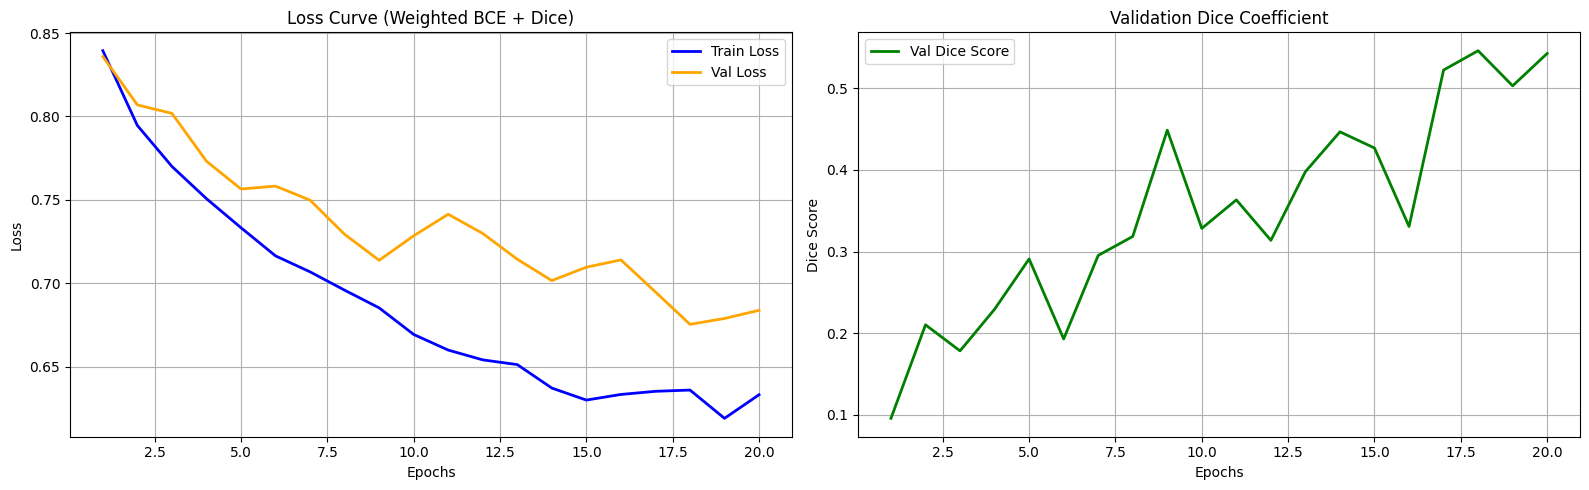

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, label='Train Loss', color='blue', linewidth=2)
axes[0].plot(epochs_range, val_losses, label='Val Loss', color='orange', linewidth=2)
axes[0].set_title('Loss Curve (Weighted BCE + Dice)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, val_dices, label='Val Dice Score', color='green', linewidth=2)
axes[1].set_title('Validation Dice Coefficient')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Dice Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


# 9. 3D Slice Segmentation Visualization

Loads the best trained checkpoint and visualizes 2D slice projections (Axial, Coronal, Sagittal) comparing Original CT, Ground Truth Mask, and 3D U-Net Segmentation Prediction.


Loaded best checkpoint: best_3d_unet_lung.pth


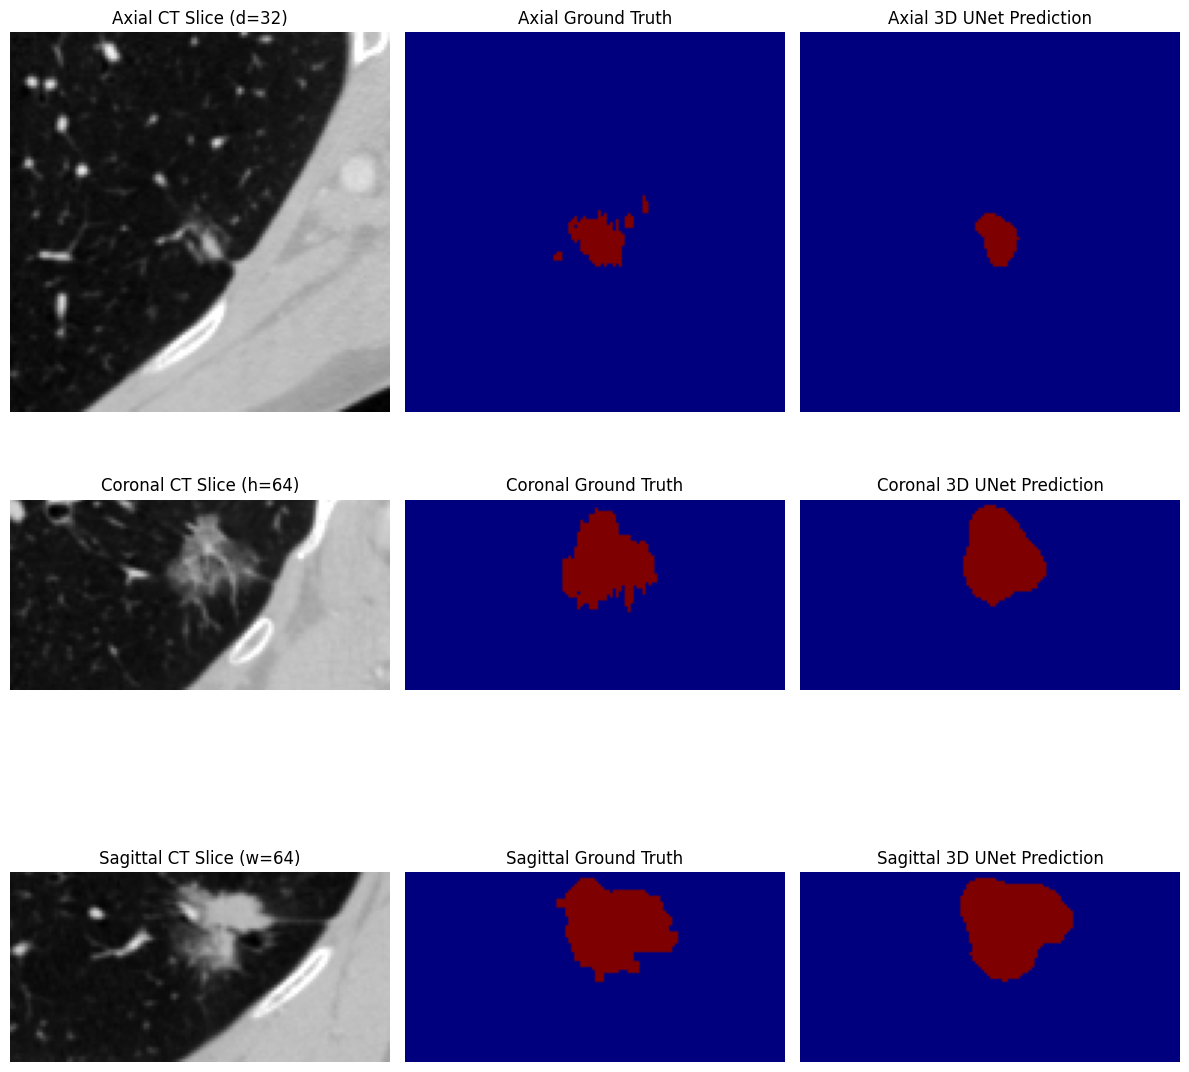

In [16]:
# Load best model checkpoint
if os.path.exists("best_3d_unet_lung.pth"):
    model.load_state_dict(torch.load("best_3d_unet_lung.pth", map_location=device))
    print("Loaded best checkpoint: best_3d_unet_lung.pth")

model.eval()

# Select one sample from validation set
val_sample = next(iter(val_loader))
val_img = val_sample["image"].to(device)
val_lbl = val_sample["label"].to(device)

with torch.no_grad():
    val_pred_logits = model(val_img)
    val_pred_prob = torch.sigmoid(val_pred_logits)
    val_pred_mask = (val_pred_prob > 0.5).float()

# Move tensors to CPU for plotting
img_np = val_img[0, 0].cpu().numpy()       # Shape: (D, H, W)
lbl_np = val_lbl[0, 0].cpu().numpy()       # Shape: (D, H, W)
pred_np = val_pred_mask[0, 0].cpu().numpy() # Shape: (D, H, W)

depth, height, width = img_np.shape
slice_d, slice_h, slice_w = depth // 2, height // 2, width // 2

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# Axial view (Depth slice)
axes[0, 0].imshow(img_np[slice_d, :, :], cmap='gray')
axes[0, 0].set_title(f'Axial CT Slice (d={slice_d})')
axes[0, 1].imshow(lbl_np[slice_d, :, :], cmap='jet')
axes[0, 1].set_title('Axial Ground Truth')
axes[0, 2].imshow(pred_np[slice_d, :, :], cmap='jet')
axes[0, 2].set_title('Axial 3D UNet Prediction')

# Coronal view (Height slice)
axes[1, 0].imshow(img_np[:, slice_h, :], cmap='gray')
axes[1, 0].set_title(f'Coronal CT Slice (h={slice_h})')
axes[1, 1].imshow(lbl_np[:, slice_h, :], cmap='jet')
axes[1, 1].set_title('Coronal Ground Truth')
axes[1, 2].imshow(pred_np[:, slice_h, :], cmap='jet')
axes[1, 2].set_title('Coronal 3D UNet Prediction')

# Sagittal view (Width slice)
axes[2, 0].imshow(img_np[:, :, slice_w], cmap='gray')
axes[2, 0].set_title(f'Sagittal CT Slice (w={slice_w})')
axes[2, 1].imshow(lbl_np[:, :, slice_w], cmap='jet')
axes[2, 1].set_title('Sagittal Ground Truth')
axes[2, 2].imshow(pred_np[:, :, slice_w], cmap='jet')
axes[2, 2].set_title('Sagittal 3D UNet Prediction')

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()
